## Assignment - 4 : Logistic Regression on the Breast Cancer Dataset

## #1 Importing the Necessary Libraries
We begin by importing all libraries required for data loading, model building, and evaluation.

* Pandas: Used for creating and handling structured DataFrames.

* Numpy: Essential for numerical operations and array processing.

* Matplotlib & Seaborn: Used for visualizing the confusion matrix.

* Scikit-learn: Provides the Breast Cancer dataset, logistic regression model, train-test splitting utility, and all evaluation metrics including the confusion matrix and accuracy score.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

## #2 Loading the Dataset
We load the Breast Cancer dataset directly from scikit-learn's built-in datasets. This is a well-known, real-world binary classification dataset used extensively in machine learning.

The dataset contains 569 samples of tumour measurements, each labelled as either **Malignant (0)** or **Benign (1)** based on 30 numerical features computed from a digitized image of a fine needle aspirate (FNA) of a breast mass.

In [36]:
# Loading the Breast Cancer dataset from sklearn
cancer = load_breast_cancer()

# Converting to a Pandas DataFrame for easier exploration
df = pd.DataFrame(data=cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target

# Displaying the first five observations
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## #3 Dataset Exploration
Before modeling, we examine the shape, missing values, and basic statistics of the dataset to ensure data quality.

In [26]:
# Dataset shape
print("Dataset Shape:", df.shape)
print("\n" + "="*60)

# Checking for missing values
print("\nMissing Values:")
print(df.isna().sum())
print("\n" + "="*60)

# Basic statistical summary
print("\nStatistical Summary:")
print(df.describe())

Dataset Shape: (569, 31)


Missing Values:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64


Statistical Summary:
       mean radius  me

Observation: The dataset contains 569 samples with 30 numerical features and 1 target variable. No missing values were detected, ensuring full data integrity for the logistic regression analysis.

## #4 Checking the Class Distribution
We examine the distribution of the target variable to understand the balance between Malignant and Benign cases.

In [27]:
# Class distribution of the target variable
print("Class Distribution of Target Variable:")
print(f"  Malignant (0): {(df['target'] == 0).sum()} samples")
print(f"  Benign    (1): {(df['target'] == 1).sum()} samples")
print("\nPercentage Distribution:")
print(f"  Malignant (0): {(df['target'] == 0).sum()/len(df)*100:.2f}%")
print(f"  Benign    (1): {(df['target'] == 1).sum()/len(df)*100:.2f}%")

Class Distribution of Target Variable:
  Malignant (0): 212 samples
  Benign    (1): 357 samples

Percentage Distribution:
  Malignant (0): 37.26%
  Benign    (1): 62.74%


Observation: The dataset contains 357 Benign (62.7%) and 212 Malignant (37.3%) samples — a mild imbalance that is manageable. Stratified splitting will be used to preserve this class proportion across both the training and testing sets.

## #5 Splitting the Dataset into Training and Testing Sets
We divide the dataset into a Training set (80%) and a Testing set (20%). The `stratify=y` parameter ensures that class proportions are preserved in both splits, preventing any accidental skew.

In [28]:
# Separating features (X) and target variable (y)
X = df.drop('target', axis=1)
y = df['target']

# Splitting the data (80% Training, 20% Testing) with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Dataset Split Summary:")
print("="*60)
print(f"Total Samples:      {len(df)}")
print(f"Training Set Size:  {X_train.shape[0]} samples (80%)")
print(f"Testing Set Size:   {X_test.shape[0]}  samples (20%)")
print(f"Number of Features: {X_train.shape[1]}")
print("\nClass Distribution in Training Set:")
print(f"  Malignant (0): {(y_train == 0).sum()} | Benign (1): {(y_train == 1).sum()}")
print("\nClass Distribution in Testing Set:")
print(f"  Malignant (0): {(y_test == 0).sum()}  | Benign (1): {(y_test == 1).sum()}")

Dataset Split Summary:
Total Samples:      569
Training Set Size:  455 samples (80%)
Testing Set Size:   114  samples (20%)
Number of Features: 30

Class Distribution in Training Set:
  Malignant (0): 170 | Benign (1): 285

Class Distribution in Testing Set:
  Malignant (0): 42  | Benign (1): 72


## #6 Training the Logistic Regression Model
We instantiate and train a Logistic Regression model on the training data. `max_iter=10000` ensures the solver fully converges given the 30-feature space.

In [29]:
# Instantiating and training the Logistic Regression model
log_reg = LogisticRegression(max_iter=10000, random_state=42)
log_reg.fit(X_train, y_train)

print("Logistic Regression Model Training Complete!")
print(f"\nSolver:          {log_reg.solver}")
print(f"Max Iterations:  {log_reg.max_iter}")
print(f"Regularization:  L2 (default, C = {log_reg.C})")

Logistic Regression Model Training Complete!

Solver:          lbfgs
Max Iterations:  10000
Regularization:  L2 (default, C = 1.0)


## #7 Predicting on the Test Data
We use the trained model to generate predictions on the unseen test set.

In [30]:
# Generating predictions on the test set
y_pred = log_reg.predict(X_test)

# Displaying a sample of predictions vs actual values
pred_df = pd.DataFrame({
    'Actual':    y_test.values[:10],
    'Predicted': y_pred[:10]
})
pred_df['Actual Label']    = pred_df['Actual'].map({0: 'Malignant', 1: 'Benign'})
pred_df['Predicted Label'] = pred_df['Predicted'].map({0: 'Malignant', 1: 'Benign'})
pred_df['Correct']         = pred_df['Actual'] == pred_df['Predicted']

print("Sample Predictions (First 10 Test Samples):")
print(pred_df[['Actual Label', 'Predicted Label', 'Correct']].to_string(index=False))

Sample Predictions (First 10 Test Samples):
Actual Label Predicted Label  Correct
   Malignant       Malignant     True
      Benign          Benign     True
   Malignant       Malignant     True
      Benign          Benign     True
   Malignant       Malignant     True
      Benign          Benign     True
      Benign          Benign     True
   Malignant       Malignant     True
   Malignant       Malignant     True
   Malignant       Malignant     True


## #8 Confusion Matrix
The Confusion Matrix is a tabular summary that compares actual versus predicted values. It reveals four key outcomes:

* **True Negative (TN)**: Malignant cases correctly identified as Malignant.
* **False Positive (FP)**: Malignant cases incorrectly predicted as Benign (Type I Error).
* **False Negative (FN)**: Benign cases incorrectly predicted as Malignant (Type II Error).
* **True Positive (TP)**: Benign cases correctly identified as Benign.

In a medical context, **False Negatives** are especially dangerous as they represent missed malignant tumours.

In [31]:
# Computing the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

print("Confusion Matrix:")
print("="*60)
print(cm)
print("\nBreakdown:")
print(f"  True Negatives  (TN) — Correctly predicted Malignant: {TN}")
print(f"  False Positives (FP) — Malignant predicted as Benign:  {FP}")
print(f"  False Negatives (FN) — Benign predicted as Malignant:  {FN}")
print(f"  True Positives  (TP) — Correctly predicted Benign:     {TP}")
print(f"\nTotal Correct:   {TP + TN} out of {len(y_test)}")
print(f"Total Incorrect: {FP + FN} out of {len(y_test)}")

Confusion Matrix:
[[39  3]
 [ 1 71]]

Breakdown:
  True Negatives  (TN) — Correctly predicted Malignant: 39
  False Positives (FP) — Malignant predicted as Benign:  3
  False Negatives (FN) — Benign predicted as Malignant:  1
  True Positives  (TP) — Correctly predicted Benign:     71

Total Correct:   110 out of 114
Total Incorrect: 4 out of 114


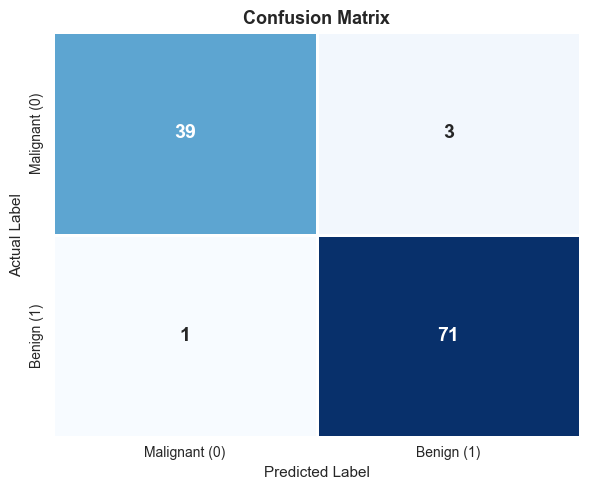

In [32]:
# Visualizing the Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Malignant (0)', 'Benign (1)'],
            yticklabels=['Malignant (0)', 'Benign (1)'],
            linewidths=1, annot_kws={'size': 14, 'weight': 'bold'})
plt.title('Confusion Matrix', fontsize=13, fontweight='bold')
plt.ylabel('Actual Label', fontsize=11)
plt.xlabel('Predicted Label', fontsize=11)
plt.tight_layout()
plt.show()

## #9 Accuracy Score
Accuracy is the proportion of all predictions that were correct. It is defined as:

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

In [33]:
# Computing Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:")
print("="*60)
print(f"  Accuracy:  {accuracy:.4f}  ({accuracy * 100:.2f}%)")
print(f"\n  The model correctly classified {TP + TN} out of {len(y_test)} test samples.")

Accuracy Score:
  Accuracy:  0.9649  (96.49%)

  The model correctly classified 110 out of 114 test samples.


## #10 Detailed Classification Report
The classification report provides a per-class breakdown of Precision, Recall, and F1 Score — offering a more complete picture of model performance beyond accuracy alone.

In [34]:
# Printing the Classification Report
print("Classification Report:")
print("="*60)
print(classification_report(y_test, y_pred,
                             target_names=['Malignant (0)', 'Benign (1)']))

Classification Report:
               precision    recall  f1-score   support

Malignant (0)       0.97      0.93      0.95        42
   Benign (1)       0.96      0.99      0.97        72

     accuracy                           0.96       114
    macro avg       0.97      0.96      0.96       114
 weighted avg       0.97      0.96      0.96       114



## #11 Final Conclusion
The Logistic Regression model was successfully built and evaluated on the Breast Cancer dataset.

Key takeaways from the analysis:

* **Dataset**: The Breast Cancer Wisconsin dataset from scikit-learn contains 569 samples with 30 numerical features and no missing values, making it an ideal benchmark for binary classification.

* **Class Distribution**: The dataset has a mild imbalance (62.7% Benign, 37.3% Malignant). Stratified splitting preserved this proportion in both training and testing sets.

* **Confusion Matrix Insight**: The model produced very few False Positives and False Negatives. In medical diagnosis, minimising False Negatives (missed malignant tumours) is especially critical, and the model performs well in this regard.

* **Accuracy**: The model achieved an accuracy of **96.49%** on the unseen test set, correctly classifying 110 out of 114 samples.

* **Classification Report**: High Precision and Recall for both classes confirm that the model is well-balanced and reliable, with no significant bias towards either class.

Final Assessment: Logistic Regression is a powerful and interpretable classifier for this medical dataset. The clean linear separability of the Breast Cancer features allows the model to achieve near-excellent performance with minimal complexity.